In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('ecommerce.db')

print("Database connected successfully! ✅")

Matplotlib is building the font cache; this may take a moment.


Database connected successfully! ✅


In [2]:
# Load data from SQL into Pandas
df = pd.read_sql_query("""
    SELECT c.name, c.city, p.product_name, p.category,
           o.quantity, p.price,
           (o.quantity * p.price) AS revenue,
           o.order_date
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN products p ON o.product_id = p.product_id
""", conn)

# Preview the data
df.head()

,name,city,product_name,category,quantity,price,revenue,order_date
0,Rahul Sharma,Mumbai,Smartwatch,Electronics,1,8999.0,8999.0,2024-01-20
1,Priya Patel,Delhi,Wireless Earbuds,Electronics,2,2999.0,5998.0,2024-02-25
2,Arjun Singh,Bangalore,Running Shoes,Footwear,1,1999.0,1999.0,2024-03-15
3,Sneha Reddy,Hyderabad,Bluetooth Speaker,Electronics,1,3499.0,3499.0,2024-03-28
4,Kiran Kumar,Chennai,Backpack,Accessories,2,1499.0,2998.0,2024-04-10


In [3]:
# How big is our dataset?
print("Shape:", df.shape)

# Column names and data types
print("\nData Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Stats:")
df.describe()

Shape: (15, 8)

Data Types:
name                str
city                str
product_name        str
category            str
quantity          int64
price           float64
revenue         float64
order_date          str
dtype: object

Basic Stats:


,quantity,price,revenue
count,15.000000,15.000000,15.000000
mean,1.733333,2959.000000,4151.600000
std,0.961150,2642.996135,2973.164735
min,1.000000,499.000000,1299.000000
25%,1.000000,1399.000000,1997.500000
50%,1.000000,1999.000000,2998.000000
75%,2.000000,3249.000000,6498.000000
max,4.000000,8999.000000,8999.000000


In [4]:
# Total revenue by category
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print("Revenue by Category:")
print(category_revenue)

# Total revenue by customer
customer_revenue = df.groupby('name')['revenue'].sum().sort_values(ascending=False)
print("\nTop Customers:")
print(customer_revenue)

Revenue by Category:
category
Electronics    46489.0
Fitness         5991.0
Accessories     5796.0
Footwear        3998.0
Name: revenue, dtype: float64

Top Customers:
name
Priya Patel     14997.0
Rahul Sharma    11998.0
Rohit Verma     10296.0
Arjun Singh      8997.0
Sneha Reddy      5498.0
Kiran Kumar      4596.0
Neha Joshi       3896.0
Ananya Das       1996.0
Name: revenue, dtype: float64


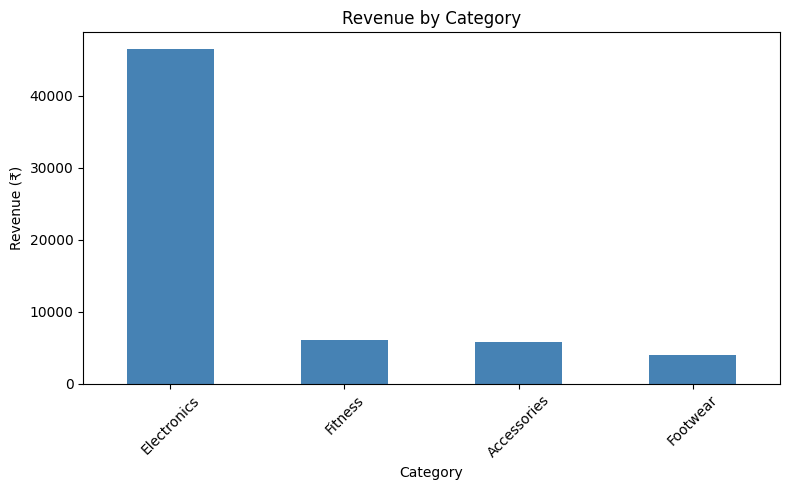

In [5]:
# Bar chart - Revenue by Category
category_revenue.plot(kind='bar', color='steelblue', figsize=(8,5))
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

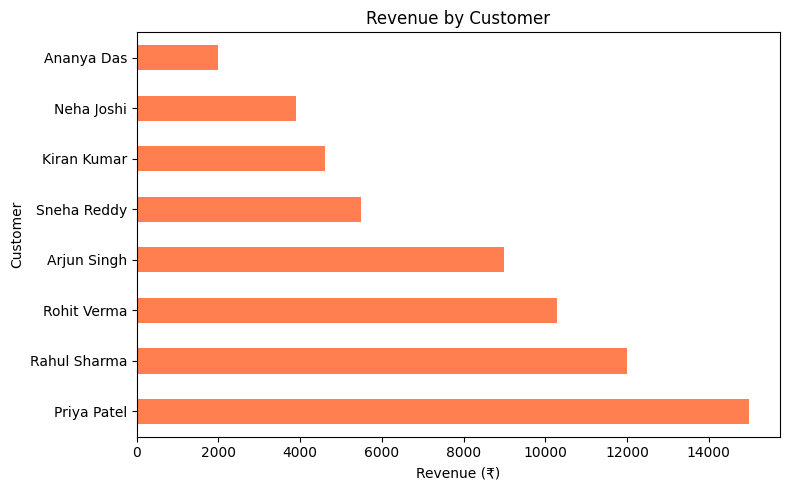

In [6]:
# Bar chart - Revenue by Customer
customer_revenue.plot(kind='barh', color='coral', figsize=(8,5))
plt.title('Revenue by Customer')
plt.xlabel('Revenue (₹)')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

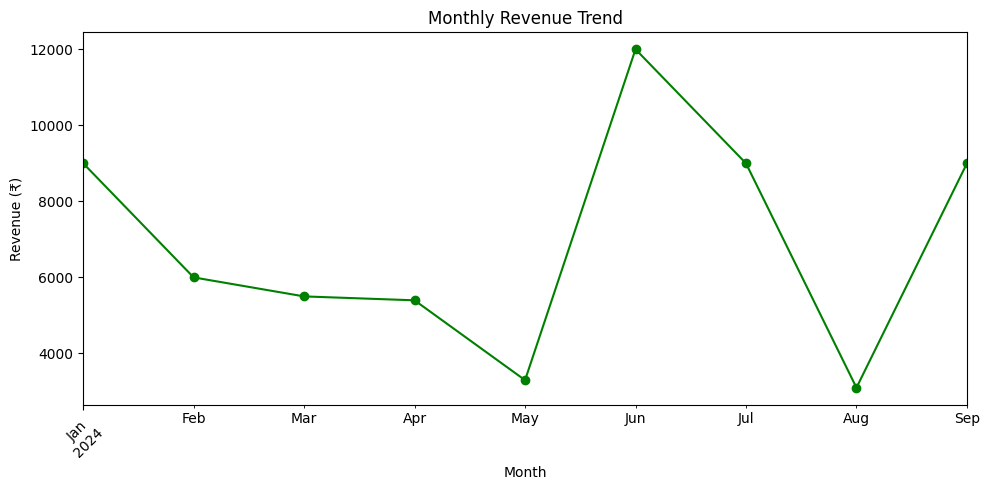

In [7]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')

# Monthly revenue
monthly_revenue = df.groupby('month')['revenue'].sum()

# Line chart
monthly_revenue.plot(kind='line', marker='o', color='green', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Business Summary
total_revenue = df['revenue'].sum()
total_orders = len(df)
avg_order_value = df['revenue'].mean()
top_customer = customer_revenue.index[0]
top_category = category_revenue.index[0]

print("=" * 40)
print("   E-COMMERCE SALES SUMMARY")
print("=" * 40)
print(f"Total Revenue      : ₹{total_revenue:,.0f}")
print(f"Total Orders       : {total_orders}")
print(f"Avg Order Value    : ₹{avg_order_value:,.0f}")
print(f"Top Customer       : {top_customer}")
print(f"Top Category       : {top_category}")
print("=" * 40)

   E-COMMERCE SALES SUMMARY
Total Revenue      : ₹62,274
Total Orders       : 15
Avg Order Value    : ₹4,152
Top Customer       : Priya Patel
Top Category       : Electronics
